In [1]:
import os
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from collections import Counter

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
base_path = r"C:\Users\FATIMA\OneDrive\Documents\plant_disease_project\dataset"

train_dir = os.path.join(base_path, "train")
val_dir   = os.path.join(base_path, "val")
test_dir  = os.path.join(base_path, "test")

In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [5]:
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [6]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_transforms)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_transforms)

In [7]:
print("Classes:", train_dataset.classes)
print("Number of classes:", len(train_dataset.classes))

Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Number of classes: 15


In [8]:
class_counts = Counter([label for _, label in train_dataset.samples])
print("Class counts:", class_counts)

Class counts: Counter({12: 2245, 5: 1488, 7: 1336, 9: 1239, 10: 1173, 14: 1113, 1: 1034, 11: 982, 2: 700, 3: 700, 6: 700, 0: 697, 8: 666, 13: 261, 4: 106})


In [9]:
num_classes = len(train_dataset.classes)
total_samples = len(train_dataset)

class_weights = torch.tensor([
    total_samples / (num_classes * class_counts[i])
    for i in range(num_classes)
], dtype=torch.float)

print("Class weights:", class_weights)

Class weights: tensor([1.3812, 0.9310, 1.3752, 1.3752, 9.0818, 0.6470, 1.3752, 0.7206, 1.4454,
        0.7770, 0.8207, 0.9803, 0.4288, 3.6884, 0.8649])


In [10]:
sample_weights = [class_weights[label] for _, label in train_dataset.samples]

In [11]:
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

In [13]:
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [14]:
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [15]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)   # Expected: [32, 3, 224, 224]
print("Label batch shape:", labels.shape)

c:\Users\FATIMA\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.3502399].


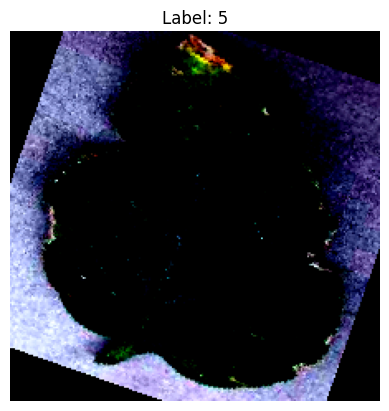

In [16]:
import matplotlib.pyplot as plt

img = images[0].permute(1, 2, 0).cpu().numpy()
plt.imshow(img)
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")
plt.show()

### Data Loading Summary

- Images are resized to 224x224.
- Data augmentation is applied only to training data.
- Validation and test data use only normalization.
- Class imbalance is handled using WeightedRandomSampler.
- Batch size is set to 32 for efficient training.

### Conclusion

- The dataset is now ready for training deep learning models.
- Balanced sampling ensures fair learning across all classes.